2026-01-04 01:49:55.811914: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767491395.986093      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767491396.036640      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767491396.461382      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767491396.461424      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767491396.461426      55 computation_placer.cc:177] computation placer alr

Found 24981 files belonging to 22 classes.
Using 19985 files for training.


I0000 00:00:1767491422.070498      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 24981 files belonging to 22 classes.
Using 4996 files for validation.
Detected Classes: ['anthracnose', 'bacterial blight', 'brown spot', 'fall armyworm', 'grasshoper', 'green mite', 'gumosis', 'healthy_cashew', 'healthy_cassava', 'healthy_maize', 'healthy_tomato', 'leaf beetle', 'leaf blight', 'leaf blight_tomato', 'leaf curl_tomato', 'leaf miner', 'leaf spot', 'mosaic', 'red rust', 'septoria leaf spot_tomato', 'streak virus', 'verticulium wilt_tomato']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "VGG19_Channel_Attention"

...

625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.9895 - loss: 0.0316 - val_accuracy: 0.8477 - val_loss: 0.9473
Epoch 23/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9915 - loss: 0.0237
Epoch 23: val_accuracy did not improve from 0.84768
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9915 - loss: 0.0238 - val_accuracy: 0.8239 - val_loss: 0.9742
Epoch 24/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9905 - loss: 0.0257
Epoch 24: val_accuracy improved from 0.84768 to 0.84968, saving model to vgg19_channel_attention.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.9905 - loss: 0.0256 - val_accuracy: 0.8497 - val_loss: 0.8745
Epoch 25/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9945 - loss: 0.0159
Epoch 25: val_accuracy did not improve from 0.84968
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9945 - loss: 0.0159 - val_accuracy: 0.8393 - val_loss: 1.0135
Epoch 26/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9914 - loss: 0.0275
Epoch 26: val_accuracy did not improve from 0.84968
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9914 - loss: 0.0275 - val_accuracy: 0.8249 - val_loss: 1.1579
Epoch 27/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9867 - loss: 0.0409
Epoch 27: val_accuracy did not improve from 0.84968
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9867 - loss: 0.0409 - val_accuracy: 0.8351 - val_loss: 1.1084
Epoch 28/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9907 - loss: 0.0265
Epoch 28: val_ac

625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.9907 - loss: 0.0265 - val_accuracy: 0.8517 - val_loss: 0.9726
Epoch 29/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9949 - loss: 0.0154
Epoch 29: val_accuracy did not improve from 0.85168
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9949 - loss: 0.0154 - val_accuracy: 0.8509 - val_loss: 0.8936
Epoch 30/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9944 - loss: 0.0170
Epoch 30: val_accuracy did not improve from 0.85168
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9944 - loss: 0.0170 - val_accuracy: 0.8331 - val_loss: 1.0406
Epoch 31/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9870 - loss: 0.0439
Epoch 31: val_accuracy did not improve from 0.85168
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9870 - loss: 0.0439 - val_accuracy: 0.8343 - val_loss: 1.1736
Epoch 32/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9925 - loss: 0.0217
Epoch 32: val_ac

625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.9899 - loss: 0.0314 - val_accuracy: 0.8561 - val_loss: 0.9642
Epoch 37/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9966 - loss: 0.0139
Epoch 37: val_accuracy improved from 0.85608 to 0.85949, saving model to vgg19_channel_attention.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.9966 - loss: 0.0139 - val_accuracy: 0.8595 - val_loss: 0.8917
Epoch 38/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9977 - loss: 0.0081
Epoch 38: val_accuracy did not improve from 0.85949
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9977 - loss: 0.0082 - val_accuracy: 0.8469 - val_loss: 1.1636
Epoch 39/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9902 - loss: 0.0331
Epoch 39: val_accuracy did not improve from 0.85949
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.9902 - loss: 0.0331 - val_accuracy: 0.8451 - val_loss: 1.0657
Epoch 40/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9946 - loss: 0.0163
Epoch 40: val_accuracy did not improve from 0.85949
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.9946 - loss: 0.0163 - val_accuracy: 0.8371 - val_loss: 1.0662
Epoch 41/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9938 - loss: 0.0204
Epoch 41: val_ac

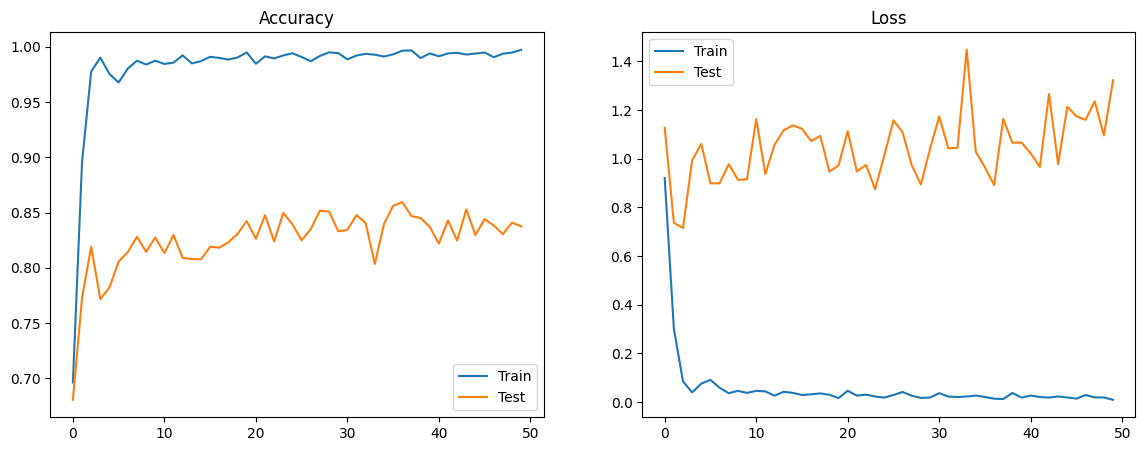


Classification Report:

                           precision    recall  f1-score   support

              anthracnose     0.9605    0.8705    0.9133       363
         bacterial blight     0.9243    0.7758    0.8436       504
               brown spot     0.7253    0.9556    0.8247       315
            fall armyworm     0.9091    0.6522    0.7595        46
               grasshoper     0.9844    0.7079    0.8235        89
               green mite     0.9202    0.8737    0.8964       198
                  gumosis     0.9868    0.9615    0.9740        78
           healthy_cashew     0.9268    0.9785    0.9520       233
          healthy_cassava     0.9425    0.9509    0.9467       224
            healthy_maize     0.6184    0.8545    0.7176        55
           healthy_tomato     0.8846    0.9020    0.8932       102
              leaf beetle     0.9349    0.9571    0.9459       210
              leaf blight     0.7251    0.6526    0.6870       190
       leaf blight_tomato     0.8344

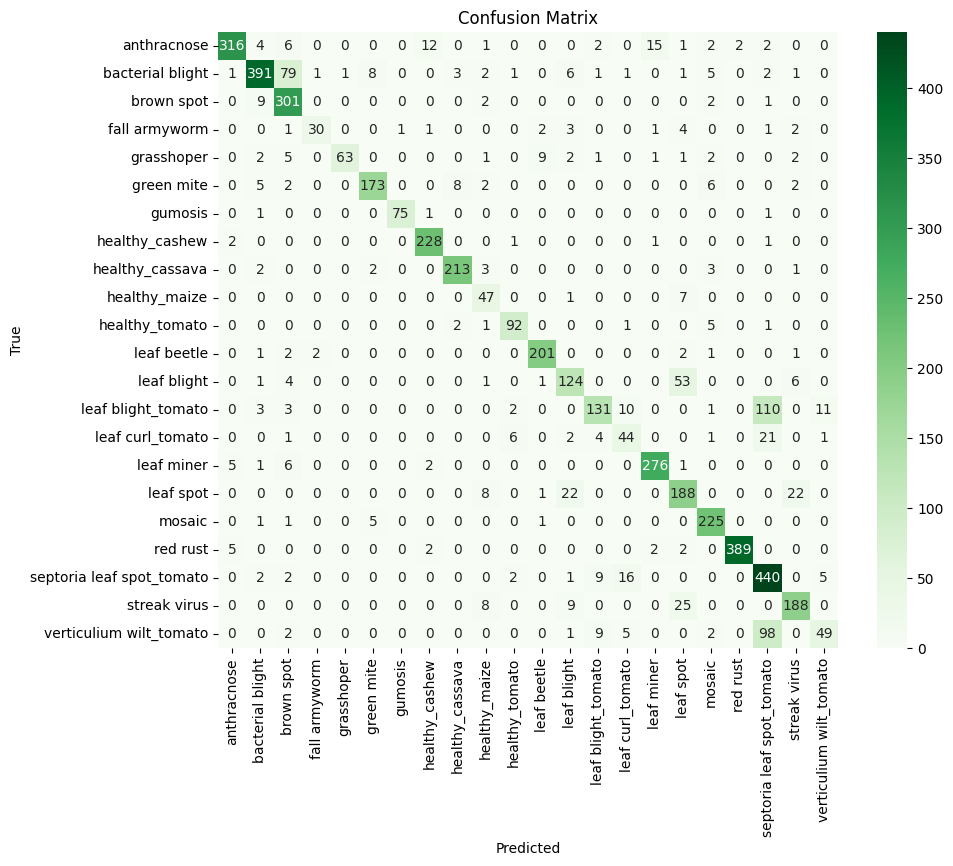

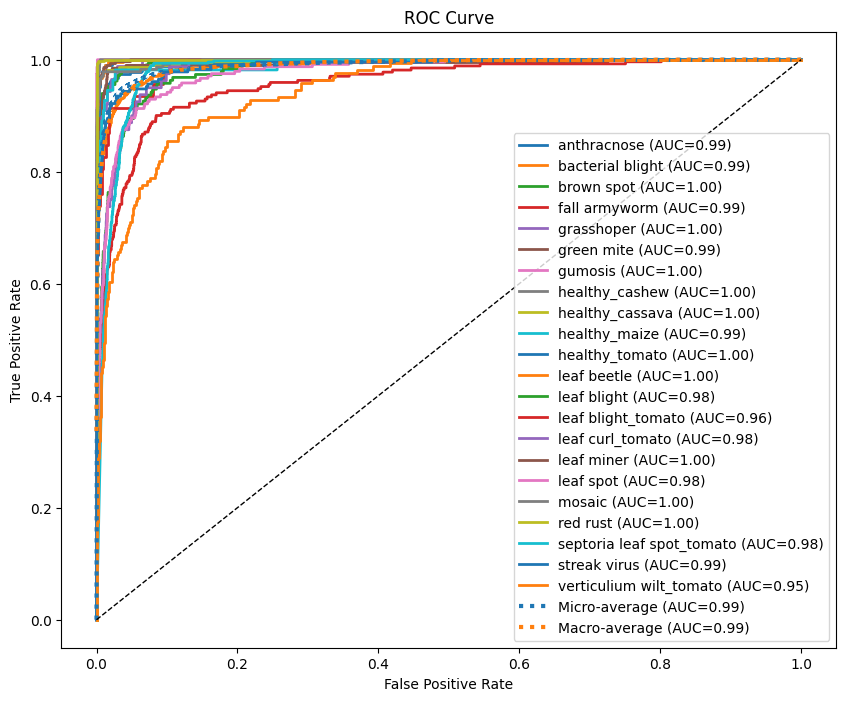

Model saved successfully.


In [1]:
# ==============================================================
# Imports
# ==============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import seaborn as sns

# ==============================================================
# Configuration
# ==============================================================
data_dir = "/kaggle/input/ccmt-2008-mnit/New folder"
img_size = (224, 224)
batch_size = 32
seed = 42
num_epochs = 50
learning_rate = 1e-4
model_save_path = "vgg19_channel_attention.h5"

# ==============================================================
# Dataset Loading (20% Train, 80% Test)
# ==============================================================
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="categorical",
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="categorical",
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Detected Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

# ==============================================================
# Channel Attention (Squeeze-and-Excitation)
# ==============================================================
def channel_attention(inputs, ratio=8):
    channel = inputs.shape[-1]

    shared_dense_1 = layers.Dense(channel // ratio, activation="relu")
    shared_dense_2 = layers.Dense(channel, activation="sigmoid")

    avg_pool = layers.GlobalAveragePooling2D()(inputs)
    avg_pool = layers.Reshape((1, 1, channel))(avg_pool)
    avg_pool = shared_dense_1(avg_pool)
    avg_pool = shared_dense_2(avg_pool)

    max_pool = layers.GlobalMaxPooling2D()(inputs)
    max_pool = layers.Reshape((1, 1, channel))(max_pool)
    max_pool = shared_dense_1(max_pool)
    max_pool = shared_dense_2(max_pool)

    scale = layers.Add()([avg_pool, max_pool])
    return layers.Multiply()([inputs, scale])

# ==============================================================
# Model Architecture (VGG19 + Channel Attention)
# ==============================================================
def build_model(input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape)

    # Normalize to [-1, 1]
    x = layers.Rescaling(1./127.5)(inputs)
    x = layers.Rescaling(1., offset=-1.0)(x)

    # VGG19 Backbone
    backbone = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    backbone.trainable = True
    x = backbone(x)

    # Channel Attention
    x = channel_attention(x, ratio=8)

    # Classification Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs, name="VGG19_Channel_Attention")

# ==============================================================
# Build & Compile
# ==============================================================
model = build_model(input_shape=img_size + (3,))
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ==============================================================
# Train Model (NO Early Stopping)
# ==============================================================
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        model_save_path,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    epochs=num_epochs,
    validation_data=test_ds,
    callbacks=callbacks
)

# ==============================================================
# Plot Accuracy & Loss
# ==============================================================
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Test")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Test")
plt.title("Loss")
plt.legend()

plt.show()

# ==============================================================
# Evaluation
# ==============================================================
y_true, y_pred = [], []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# ==============================================================
# Confusion Matrix
# ==============================================================
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ==============================================================
# ROC Curve (Micro & Macro)
# ==============================================================
y_true_bin = label_binarize(y_true, classes=range(num_classes))

y_score = []
for images, _ in test_ds:
    y_score.extend(model.predict(images, verbose=0))
y_score = np.array(y_score)

fpr, tpr, roc_auc = {}, {}, {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_true_bin.ravel(),
    y_score.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= num_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot ROC
plt.figure(figsize=(10,8))
colors = cycle(plt.cm.tab10.colors)

for i, color in zip(range(num_classes), colors):
    plt.plot(
        fpr[i], tpr[i], lw=2, color=color,
        label=f"{class_names[i]} (AUC={roc_auc[i]:.2f})"
    )

plt.plot(
    fpr["micro"], tpr["micro"],
    linestyle=":", linewidth=3,
    label=f"Micro-average (AUC={roc_auc['micro']:.2f})"
)

plt.plot(
    fpr["macro"], tpr["macro"],
    linestyle=":", linewidth=3,
    label=f"Macro-average (AUC={roc_auc['macro']:.2f})"
)

plt.plot([0,1], [0,1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# ==============================================================
# Save Final Model
# ==============================================================
model.save("final_" + model_save_path)
print("Model saved successfully.")
